# Laboratorio final

**Fecha de entrega:** 09 de Julio a las 16h  
**Grupos:** 4 estudiantes  
**Integrantes:**
- García Avalos Nicolas Alan
- Espinoza Picon Diego Steven Martin
- Castro Contreras Luis Alejandro

**Dataset:** `dataset_train.csv`

## Contexto

Una empresa de servicios financieros desea clasificar automáticamente a sus clientes en tres segmentos de comportamiento (`Clase`) para personalizar campañas comerciales.

El dataset contiene información de **1 600 clientes** y presenta varios problemas comunes en proyectos reales de Machine Learning:

- columnas con valores únicos por fila;
- variables categóricas nominales;
- variables categóricas ordinales;
- variables numéricas;
- variables con escalas muy diferentes;
- alta correlación positiva entre algunas variables;
- correlación negativa entre otras variables.

El objetivo del laboratorio es construir un **pipeline completo de clasificación**, comparar modelos mediante validación cruzada, guardar el mejor modelo y evaluarlo en un conjunto de test (`dataset_test.csv`).

## Variables disponibles

| Variable | Descripción |
|---|---|
| `cliente_id` | Identificador único del cliente. |
| `region` | Región donde reside el cliente. |
| `experiencia_digital` | Nivel de experiencia digital. |
| `satisfaccion_servicio` | Nivel de satisfacción del cliente. |
| `ingreso_anual_soles` | Ingreso anual del cliente. |
| `gasto_mensual_soles` | Gasto mensual promedio. |
| `ratio_deuda` | Relación entre deuda e ingresos. |
| `indice_ahorro` | Índice de ahorro del cliente. |
| `Clase` | Segmento del cliente (objetivo) |

# Reglas del laboratorio

1. No está permitido modificar la variable objetivo `Clase`.
2. No está permitido evaluar el modelo final sobre el conjunto de entrenamiento.
3. Todo preprocesamiento debe estar dentro de un `Pipeline` o `ColumnTransformer`.
4. Todos los modelos deben evaluarse con las mismas particiones de Cross Validation.
5. El modelo final debe guardarse y luego cargarse para evaluar el conjunto de test.

# Importación de librerías

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
# Puede agregar más ...

import joblib

# Carga del dataset

In [8]:
df = pd.read_csv("Data/dataset_train.csv")
df.head()

,cliente_id,region,experiencia_digital,satisfaccion_servicio,ingreso_anual_soles,gasto_mensual_soles,ratio_deuda,indice_ahorro,clase
0,CLI-01728,Junín,Bajo,Alta,35235.60,1819.16,0.0200,0.8224,Clase_B_riesgo_medio
1,CLI-00982,La Libertad,Bajo,Baja,42260.47,2441.33,0.4725,0.3013,Clase_C_alto_riesgo
2,CLI-01611,Piura,Medio,Muy baja,73952.40,4209.44,0.5742,0.3789,Clase_B_riesgo_medio
3,CLI-00773,Lima,Alto,Media,76510.39,3539.38,0.1262,0.7369,Clase_A_bajo_riesgo
4,CLI-01069,Lima,Bajo,Baja,85832.31,3536.46,0.4723,0.3765,Clase_C_alto_riesgo


In [ ]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cliente_id             1600 non-null   str    
 1   region                 1600 non-null   str    
 2   experiencia_digital    1600 non-null   str    
 3   satisfaccion_servicio  1600 non-null   str    
 4   ingreso_anual_soles    1600 non-null   float64
 5   gasto_mensual_soles    1600 non-null   float64
 6   ratio_deuda            1600 non-null   float64
 7   indice_ahorro          1600 non-null   float64
 8   clase                  1600 non-null   str    
dtypes: float64(4), str(5)
memory usage: 112.6 KB
None


# Desafío 1: Análisis y preprocesamiento (5 PUNTOS)

Antes de entrenar modelos, respondan las siguientes preguntas:

1. ¿Qué tipo de dato tiene cada variable?
- Cliente_id = str
- region = str
- experiencia_digital = str
- satisfaccion_servicio = str
- ingreso_anual_soles = float
- ratio_deuda = float
- indice_ahorro = float
- clase = str  
2. ¿Qué variables son categóricas nominales?

- region

3. ¿Qué variables son categóricas ordinales?

- experiencia_digital, satisfaccion_servicio, clase (variable objetivo)

4. ¿Qué variables son numéricas?

- ingreso_anual_soles, ratio_deuda, indice_ahorro, gasto_mensual

5. ¿Existe alguna variable que no debería utilizarse para entrenar el modelo?

- id_cliente

6. ¿Qué variables presentan alta correlación positiva?

- ingreso_anual / gasto_mensual

7. ¿Qué variables presentan correlación negativa?

- ratio_deuda / indice_ahorro

8. ¿Qué variables tienen escalas muy diferentes?

ingreso_anual y gasto_mensual manejan escalas de miles de soles, mientras que ratio_deuda e indice_ahorro manejan datos entre 0 y 1 al ser tasas.

9. ¿La variable objetivo está balanceada?

Si, en este caso si se encuentra balanceada ya que las 3 clases definidas tienen porcentajes cercanos al 33%

Completen las celdas siguientes con análisis, gráficos y respuestas.

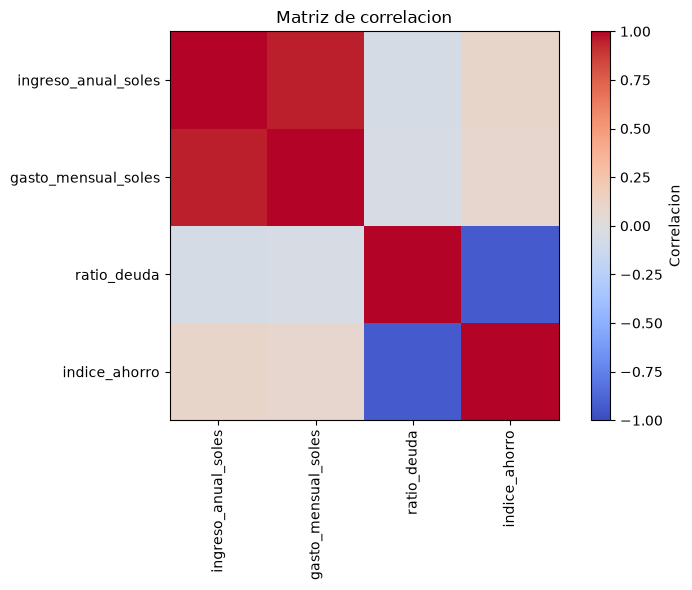

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlacion")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Matriz de correlacion")
plt.tight_layout()
plt.show()


In [ ]:
eda_numeric_cols = df.select_dtypes(include="number").columns
eda_numeric_cols

In [14]:
print(df[eda_numeric_cols].describe().loc[['min', 'max', 'mean', 'std']])

      ingreso_anual_soles  gasto_mensual_soles  ratio_deuda  indice_ahorro
min          15000.000000           634.490000     0.020000       0.010000
max         193475.440000          9566.380000     0.942500       0.980000
mean         55173.376344          2784.104719     0.308459       0.581925
std          23592.576868          1135.216269     0.175748       0.196183


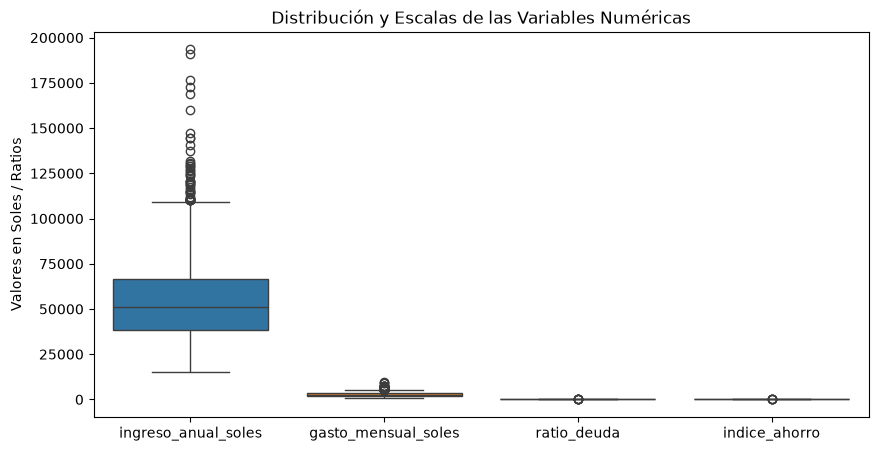

In [17]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[eda_numeric_cols])
plt.title('Distribución y Escalas de las Variables Numéricas')
plt.ylabel('Valores en Soles / Ratios')
plt.show()

In [18]:
counts = df['clase'].value_counts()
percentages = df['clase'].value_counts(normalize=True) * 100

balance_df = pd.DataFrame({'Cantidad': counts, 'Porcentaje (%)': percentages})
print(balance_df)

                      Cantidad  Porcentaje (%)
clase                                         
Clase_C_alto_riesgo        534         33.3750
Clase_B_riesgo_medio       533         33.3125
Clase_A_bajo_riesgo        533         33.3125


C:\Users\Diego\AppData\Local\Temp\ipykernel_1692\2187690524.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='clase', data=df, order=counts.index, palette='viridis')


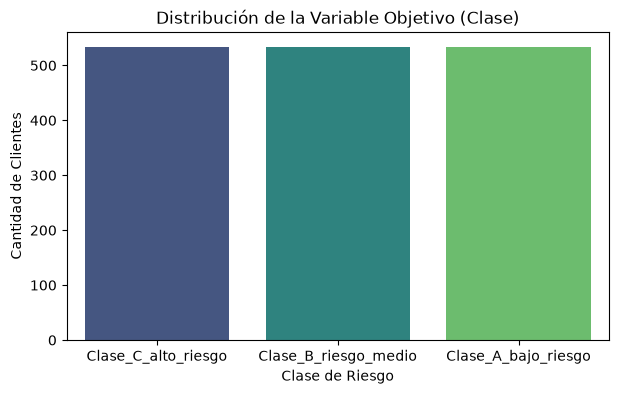

In [19]:
plt.figure(figsize=(7, 4))
sns.countplot(x='clase', data=df, order=counts.index, palette='viridis')
plt.title('Distribución de la Variable Objetivo (Clase)')
plt.xlabel('Clase de Riesgo')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(x='clase', data=df, order=counts.index, palette='viridis')
plt.title('Distribución de la Variable Objetivo (Clase)')
plt.xlabel('Clase de Riesgo')
plt.ylabel('Cantidad de Clientes')
plt.show()

## Respuestas del Desafío 1

Completen sus respuestas aquí.

**1. Variable que eliminaríamos y justificación:**  
Respuesta:

Eliminaría cliente_id, debido a que este es un identificador único que no aporta información estadística al problema planteado, y como se ha visto anteriormente, hacer uso de este  podría causar overfitting.


**2. Variables categóricas nominales:**  
Respuesta: region


**3. Variables categóricas ordinales:**  
Respuesta: experiencia_digital, satisfaccion_servicio y clase

**4. Variables numéricas:**  
Respuesta: ingreso_anual_soles, gasto_mensual_soles, ratio_deuda, indice_ahorro

**5. Variables que deberían escalarse:**  
Respuesta: 
En este caso considero que todas las variables deberían de escalarse por sus magnitudes drasticamente diferentes. 

**6. Variables con alta correlación positiva:**  
Respuesta:
Como se ve en la gráfica los valores que tienen una correlación positiva son ingreso_anual_soles y gasto_mensual_soles

**7. Variables con correlación negativa:**  
Respuesta:
Como se ve en la gráfica los valores que tienen una correlación negativa son ratio_deuda e indice_ahorro


**8. Decisiones de preprocesamiento:**  
Respuesta:

En el pre procesamiento, lo mejor será quitar el cliente_id del set de entrenamiento. 

Para las variables númericas (ingreso_anual_soles, gasto_mensual_soles, ratio_deuda, indice_ahorro) se aplicará StandardScaler 

Se aplicará OneHotEncoder a la variable region y OrdinalEncoder a experiencia_digital y satisfaccion_servicio


# Definición del preprocesamiento

Deben completar las listas de variables según sus decisiones del Desafío 1.

Sugerencia:

- `cliente_id` probablemente no debería usarse como predictor.
- `region` puede tratarse como categórica nominal.
- `experiencia_digital` y `satisfaccion_servicio` pueden tratarse como ordinales.
- Las variables numéricas pueden escalarse, especialmente para modelos sensibles a distancia o magnitud.

In [ ]:
target_col = "clase"

nominal_cols = ["region"]

ordinal_cols = [
    "experiencia_digital",
    "satisfaccion_servicio",
]

numeric_cols = [
    "ingreso_anual_soles",
    "gasto_mensual_soles",
    "ratio_deuda",
    "indice_ahorro",
]

ordinal_categories = [
    ["Bajo", "Medio", "Alto", "Muy alto"],
    ["Muy baja", "Baja", "Media", "Alta", "Muy alta"],
]

X = df.drop(columns=[target_col])
y = df[target_col]

In [ ]:
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

nominal_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

ordinal_transformer = Pipeline([
    ("ordinal", OrdinalEncoder(categories=ordinal_categories)),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("nom", nominal_transformer, nominal_cols),
        ("ord", ordinal_transformer, ordinal_cols),
    ],
    remainder="drop",
    sparse_threshold=0
)

# Desafío 2: Comparación de modelos con Cross Validation (5 PUNTOS)

Comparen al menos 2 de los siguientes modelos:

- Logistic Regression
- K-Nearest Neighbors
- Decision Tree
- Random Forest
- MLP

Todos deben evaluarse con:

- 5-Fold Cross Validation.
- Las mismas particiones.
- Métricas: Accuracy, Precision macro, Recall macro y F1 macro.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro"
}

In [ ]:
cv_results = {}
summary_rows = []

for model_name, model in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )

    cv_results[model_name] = scores

    summary_rows.append({
        "model": model_name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "precision_macro_mean": scores["test_precision_macro"].mean(),
        "precision_macro_std": scores["test_precision_macro"].std(),
        "recall_macro_mean": scores["test_recall_macro"].mean(),
        "recall_macro_std": scores["test_recall_macro"].std(),
        "f1_macro_mean": scores["test_f1_macro"].mean(),
        "f1_macro_std": scores["test_f1_macro"].std(),
    })

results_df = pd.DataFrame(summary_rows)
results_df = results_df.sort_values("f1_macro_mean", ascending=False).reset_index(drop=True)
results_df.round(4)

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(
    results_df["model"],
    results_df["f1_macro_mean"],
    yerr=results_df["f1_macro_std"],
    capsize=4,
    color="steelblue"
)
plt.title("Comparación de modelos por F1 macro promedio")
plt.xlabel("Modelo")
plt.ylabel("F1 macro promedio")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## Selección del mejor modelo

Completen:

**Mejor modelo elegido:**  
Respuesta:

**Métrica principal utilizada para elegirlo:**  
Respuesta:

**Justificación:**  
Respuesta:

# Entrenamiento final del mejor modelo

Una vez elegido el mejor modelo con Cross Validation, entrenen el pipeline final usando todo el conjunto de entrenamiento.   

In [ ]:
best_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

best_pipeline.fit(X, y)
best_pipeline

# Desafío 3: Guardar el modelo y crear función de evaluación (5 PUNTOS)

El modelo debe guardarse en disco y luego cargarse desde una función de evaluación.

In [ ]:
# TODO: Guardar el pipeline completo (libreria joblib)
model_path = "best_model.pkl"
joblib.dump(best_pipeline, model_path)
print(f"Pipeline guardado en {model_path}")

In [ ]:
def evaluate(model_path, X_test, y_test):
    """
    Carga un modelo previamente almacenado y lo evalúa sobre un conjunto de prueba.

    Parámetros
    ----------
    model_path : str
        Ruta del archivo .pkl que contiene el pipeline completo.
    X_test : DataFrame
        Variables predictoras del conjunto de prueba.
    y_test : Series
        Etiquetas reales del conjunto de prueba.

    Retorna
    -------
    y_pred : array
        Predicciones generadas por el modelo.
    """
    model = joblib.load(model_path)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision macro: {precision:.4f}")
    print(f"Recall macro: {recall:.4f}")
    print(f"F1-score macro: {f1:.4f}")
    print()
    print("Classification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    labels = np.unique(np.concatenate([np.asarray(y_test), np.asarray(y_pred)]))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, labels=labels)
    plt.title("Matriz de confusión")
    plt.xticks(rotation=15)
    plt.show()

    return y_pred

In [ ]:
df_test = pd.read_csv("Data/dataset_test.csv")
X_test = df_test.drop(columns=[target_col])
y_test = df_test[target_col]

# Prueba del pipeline con un subconjunto de 20 observaciones

Antes de evaluar todo el conjunto de test, prueben el pipeline con 20 observaciones.

In [ ]:
X_subset = X_test.sample(20, random_state=42)
y_subset = y_test.loc[X_subset.index]

y_pred_subset = evaluate(model_path, X_subset, y_subset)

pd.DataFrame({
    "Clase real": y_subset.values,
    "Clase predicha": y_pred_subset
})

# Desafío 4: Evaluación final en conjunto de test (5 PUNTOS)

Este es el resultado final del laboratorio.

Deben evaluar el modelo guardado sobre todo el conjunto de test y reportar las métricas finales.

Importante:

- El conjunto de test no debe usarse para seleccionar modelos.
- Solo debe utilizarse al final.
- El resultado principal para la competencia será el **F1-score macro**.

In [ ]:
# TODO: Evaluación final sobre todo el conjunto de test

y_pred_test = evaluate(model_path, X_test, y_test)

In [ ]:
# TODO: Guardar predicciones finales

final_results = X_test.copy()
final_results["Clase real"] = y_test.values
final_results["Clase predicha"] = y_pred_test

final_results.to_csv("resultados_test.csv", index=False)
final_results.head()

# Desafío 5: Entrena tu mejor modelo
## Este desafío tiene nota doble y aparte. (20 PUNTOS)

Explora con [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) los parámetros de los modelos (MLP, ensambles, regresión logística, etc) y encuentre el **MEJOR** modelo aplicando el código anteriormente desarrollado.

Al final el mejor modelo deberá ser probado en el conjunto de test.

# Regla de calificación por desempeño

La nota máxima de desempeño será **20** y se asignará al grupo que obtenga el mejor resultado en el conjunto de test, usando como métrica principal:

## F1-score macro

Los demás grupos serán calificados en función de la distancia entre su resultado y el mejor resultado obtenido en la clase.

Una posible regla de asignación es:

```python
nota_grupo = 20 * (f1_grupo / f1_mejor)
```

Por ejemplo, si el mejor grupo obtiene `F1 = 0.90` y otro grupo obtiene `F1 = 0.81`, entonces:

```python
nota = 20 * (0.81 / 0.90) = 18
```

## Penalización por resultados idénticos

Si todos los grupos presentan exactamente los mismos resultados, se aplicará una penalización de **-5 puntos a todos los grupos**, debido a que esto sugiere copia o falta de exploración experimental.

Para evitar esto, cada grupo debe justificar sus decisiones y explorar al menos una variante propia del pipeline o del modelo.

# Entregables

Al finalizar el laboratorio, cada grupo deberá entregar:

1. Notebook completamente ejecutado.
2. Archivo `best_model.pkl`.
3. Archivo `resultados_test.csv`.
4. Gráfico comparativo de modelos.
5. Respuestas a desafíos.
6. F1-score macro final obtenido sobre el conjunto de test.